# Урок 1.2. Функции потерь и лучшая константа

**Интерактивная версия:** `lessons/lesson_1_2/web/index.html`

После урока вы сможете:
- посчитать эмпирический риск руками и отличить его от истинного;
- сравнить квадратичные, абсолютные, Хьюбера и квантильные потери;
- найти лучшую константу для каждой потери и объяснить её как равновесие сил;
- оценить чувствительность к выбросам и выбрать квантиль по несимметричной цене ошибок;
- объяснить, что предсказывает модель с данной потерей: условное среднее, медиану, квантиль;
- связать потерю с допущением о шуме через правдоподобие;
- вычислить псевдо-остатки $-\partial L/\partial F$, лучшую вероятность и стартовый логит;
- пройти первый шаг бустинга руками: старт, псевдо-остатки, пень, значения листьев.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np

from gbcourse import GBRegressor, datasets, get_loss, style
from gbcourse.metrics import mse
from gbcourse.plotting import plot_data, plot_loss_functions, plot_truth, use_course_style
from gbcourse.rng import Mulberry32

use_course_style()

## 1. Формы потерь и их градиентов

Слева — цена ошибки $L(r)$, справа — псевдо-остаток $-\partial L/\partial F$: чему будет учиться дерево.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


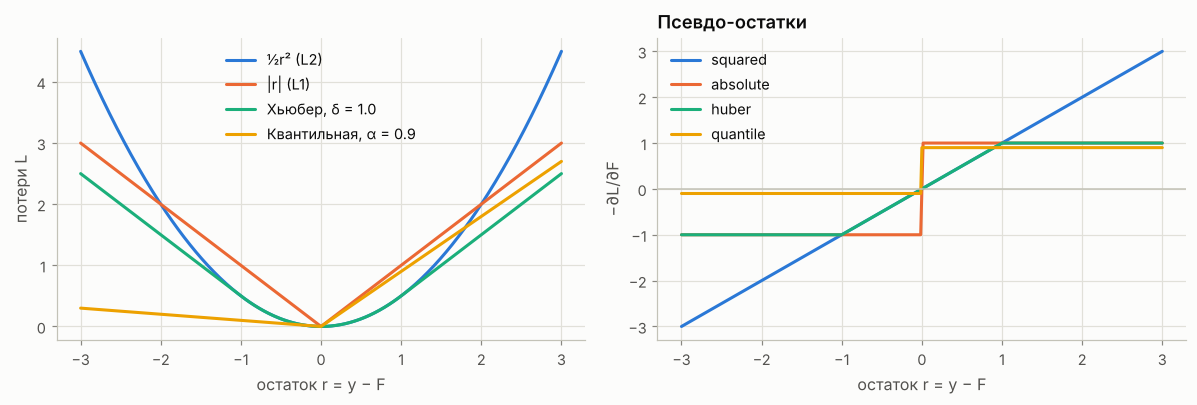

squared   L(r) = [ 0.125  0.5    2.    12.5   50.   ]   ошибка 10 дороже ошибки 1 в 100 раз
absolute  L(r) = [ 0.5  1.   2.   5.  10. ]   ошибка 10 дороже ошибки 1 в 10 раз
huber     L(r) = [0.125 0.5   1.5   4.5   9.5  ]   ошибка 10 дороже ошибки 1 в 19 раз
quantile  L(r) = [0.45 0.9  1.8  4.5  9.  ]   ошибка 10 дороже ошибки 1 в 10 раз


In [2]:
r = np.linspace(-3, 3, 401)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
plot_loss_functions(axes[0], names=("squared", "absolute", "huber", "quantile"), r_max=3, delta=1.0, alpha=0.9)
for (name, kw), color in zip([("squared", {}), ("absolute", {}), ("huber", {"delta": 1.0}), ("quantile", {"alpha": 0.9})], style.SERIES):
    loss = get_loss(name, **kw)
    axes[1].plot(r, loss.negative_gradient(r, np.zeros_like(r)), color=color, label=name)
axes[1].axhline(0, color=style.AXIS, lw=1)
axes[1].set(xlabel="остаток r = y − F", ylabel="−∂L/∂F", title="Псевдо-остатки")
axes[1].legend()
fig.tight_layout()
plt.show()

# Как растёт цена: ошибка 10 против ошибки 1
rr = np.array([0.5, 1, 2, 5, 10.0])
for name, kw in [("squared", {}), ("absolute", {}), ("huber", {"delta": 1.0}), ("quantile", {"alpha": 0.9})]:
    v = get_loss(name, **kw).pointwise(rr, np.zeros_like(rr))
    print(f"{name:9s} L(r) = {v}   ошибка 10 дороже ошибки 1 в {v[-1] / v[1]:.0f} раз")

## 2. Эмпирический риск: шесть квартир

Правило риелтора из урока 1.1 ошибается на шести квартирах на $+1, +1, -2, 0, -1, +1$.
Риск — средние потери; у разных потерь он в разных «валютах».

In [3]:
r6 = np.array([1, 1, -2, 0, -1, 1.0])
for name, kw in [("squared", {}), ("absolute", {}), ("huber", {"delta": 1.0}), ("quantile", {"alpha": 0.9})]:
    loss = get_loss(name, **kw)
    print(f"{name:9s} потери {loss.pointwise(r6, np.zeros(6))}  риск {loss.loss(r6, np.zeros(6)):.3f}")

squared   потери [0.5 0.5 2.  0.  0.5 0.5]  риск 0.667
absolute  потери [1. 1. 2. 0. 1. 1.]  риск 1.000
huber     потери [0.5 0.5 1.5 0.  0.5 0.5]  риск 0.583
quantile  потери [0.9 0.9 0.2 0.  0.1 0.9]  риск 0.500


## 3. Считаем руками: пять чисел

$y = (1, 2, 3, 4, 10)$. Сравним константы $c = 3$ (медиана) и $c = 4$ (среднее) и посмотрим, какую долю
суммы даёт точка 10.

In [4]:
y = np.array([1, 2, 3, 4, 10.0])
for c in (3, 4, 5):
    rr = y - c
    sq = 0.5 * rr**2
    print(f"c = {c}: Σ½r² = {sq.sum():5.1f} (доля точки 10 — {sq[-1] / sq.sum():.0%})   Σ|r| = {np.sum(np.abs(rr)):4.1f}")

c = 3: Σ½r² =  27.5 (доля точки 10 — 89%)   Σ|r| = 11.0
c = 4: Σ½r² =  25.0 (доля точки 10 — 72%)   Σ|r| = 12.0
c = 5: Σ½r² =  27.5 (доля точки 10 — 45%)   Σ|r| = 15.0


## 4. Лучшая константа — численно и формулой

Переберём $c$ на сетке и сравним с формулами. Для квантиля видна тонкость: точный минимизатор — наблюдение
с номером $\lceil \alpha n \rceil$, а `np.quantile` и `loss.init` интерполируют между соседями.

squared   численный минимум  4.000   loss.init = 4.000
absolute  численный минимум  3.000   loss.init = 3.000
huber     численный минимум  3.250   loss.init = 3.000


quantile  численный минимум 10.000   loss.init = 7.600


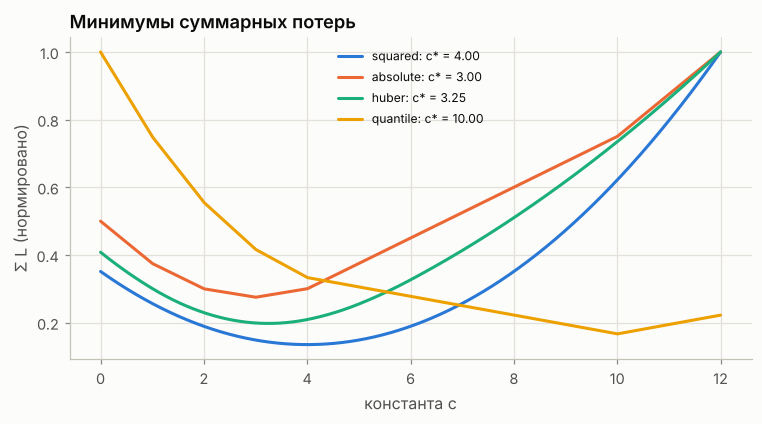

точная 0.9-квантиль: 10.0   np.quantile: 7.6000000000000005
[2. 8.]: среднее 5.00, медиана 5.00
[ 2.  3. 10.]: среднее 5.00, медиана 3.00
[ 1.  2.  3.  4. 10.]: среднее 4.00, медиана 3.00


In [5]:
cs = np.linspace(0, 12, 12001)
fig, ax = plt.subplots(figsize=(8, 3.8))
for (name, kw), color in zip([("squared", {}), ("absolute", {}), ("huber", {"delta": 3.0}), ("quantile", {"alpha": 0.9})], style.SERIES):
    loss = get_loss(name, **kw)
    total = np.array([loss.pointwise(y, np.full_like(y, c)).sum() for c in cs])
    c_star = cs[np.argmin(total)]
    ax.plot(cs, total / total.max(), color=color, label=f"{name}: c* = {c_star:.2f}")
    print(f"{name:9s} численный минимум {c_star:6.3f}   loss.init = {loss.init(y):.3f}")
ax.set(xlabel="константа c", ylabel="Σ L (нормировано)", title="Минимумы суммарных потерь")
ax.legend(fontsize=8)
plt.show()
print("точная 0.9-квантиль:", np.sort(y)[int(np.ceil(0.9 * len(y))) - 1], "  np.quantile:", np.quantile(y, 0.9))

# Лестница: две, три и пять точек
for ys in ([2, 8.0], [2, 3, 10.0], [1, 2, 3, 4, 10.0]):
    ys = np.array(ys)
    print(f"{ys}: среднее {ys.mean():.2f}, медиана {np.median(ys):.2f}")

## 5. Равновесие сил

В минимуме сумма антиградиентов $\sum_i -\partial L(y_i, c)/\partial c$ равна нулю. Проверим для гладких потерь.
И разложение без производных: $\sum (y_i - c)^2 = \sum (y_i - \bar y)^2 + n(\bar y - c)^2$.

In [6]:
for name, kw, c in [("squared", {}, y.mean()), ("huber", {"delta": 3.0}, 3.25)]:
    g = get_loss(name, **kw).negative_gradient(y, np.full_like(y, c))
    print(f"{name:8s} c = {c}: силы {g}, сумма {g.sum():+.2e}")
for c in (3.0, 5.0, 6.5):
    lhs = np.sum((y - c) ** 2)
    rhs = np.sum((y - y.mean()) ** 2) + len(y) * (y.mean() - c) ** 2
    print(f"c = {c}: Σ(y − c)² = {lhs:.2f} = {np.sum((y - y.mean()) ** 2):.0f} + 5·{(y.mean() - c) ** 2:.2f} = {rhs:.2f}")

squared  c = 4.0: силы [-3. -2. -1. -0.  6.], сумма +0.00e+00
huber    c = 3.25: силы [-2.25 -1.25 -0.25  0.75  3.  ], сумма +0.00e+00
c = 3.0: Σ(y − c)² = 55.00 = 50 + 5·1.00 = 55.00
c = 5.0: Σ(y − c)² = 55.00 = 50 + 5·1.00 = 55.00
c = 6.5: Σ(y − c)² = 81.25 = 50 + 5·6.25 = 81.25


## 6. Выбросы: кривая чувствительности

Восемь обычных значений и одна подвижная точка $z$. Куда уходит лучшая константа?

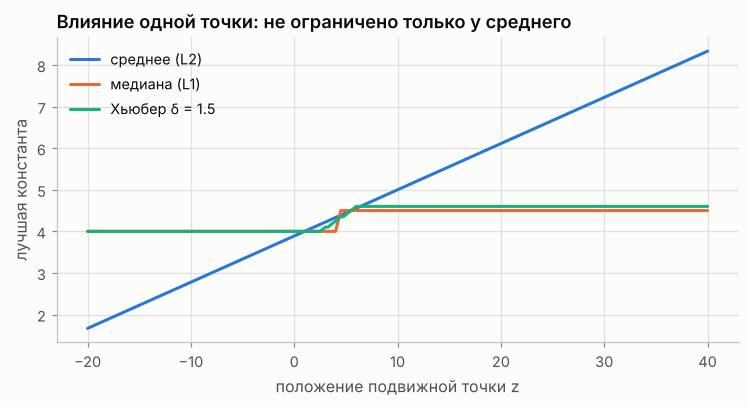

пятое число    10: среднее     4.0, медиана 3
пятое число   100: среднее    22.0, медиана 3
пятое число  1000: среднее   202.0, медиана 3


In [7]:
base = np.array([2, 3, 3.5, 4, 4.5, 5, 6, 7.0])
zs = np.linspace(-20, 40, 241)
huber = get_loss("huber", delta=1.5)
grid = np.linspace(-20, 40, 6001)


def huber_const(values: np.ndarray) -> float:
    return grid[np.argmin([huber.pointwise(values, np.full_like(values, c)).sum() for c in grid[::5]]) * 5]


curves = {"среднее (L2)": [], "медиана (L1)": [], "Хьюбер δ = 1.5": []}
for z in zs:
    v = np.append(base, z)
    curves["среднее (L2)"].append(v.mean())
    curves["медиана (L1)"].append(np.median(v))
    curves["Хьюбер δ = 1.5"].append(huber_const(v))
fig, ax = plt.subplots(figsize=(8, 3.6))
for (name, c), color in zip(curves.items(), style.SERIES):
    ax.plot(zs, c, color=color, label=name)
ax.set(xlabel="положение подвижной точки z", ylabel="лучшая константа", title="Влияние одной точки: не ограничено только у среднего")
ax.legend()
plt.show()

for big in (10, 100, 1000):
    v = np.array([1, 2, 3, 4, big], dtype=float)
    print(f"пятое число {big:5d}: среднее {v.mean():7.1f}, медиана {np.median(v):.0f}")

## 7. Несимметричная цена: сколько минут обещать

60 прошлых доставок. Минута опоздания в $k$ раз дороже минуты запаса — оптимальное обещание
равно $\frac{k}{k+1}$-квантили.

k =  1: α = 0.500, обещать 28.5 мин, опозданий 50%
k =  4: α = 0.800, обещать 33.6 мин, опозданий 20%
k =  9: α = 0.900, обещать 35.0 мин, опозданий 10%
k = 19: α = 0.950, обещать 36.4 мин, опозданий 5%


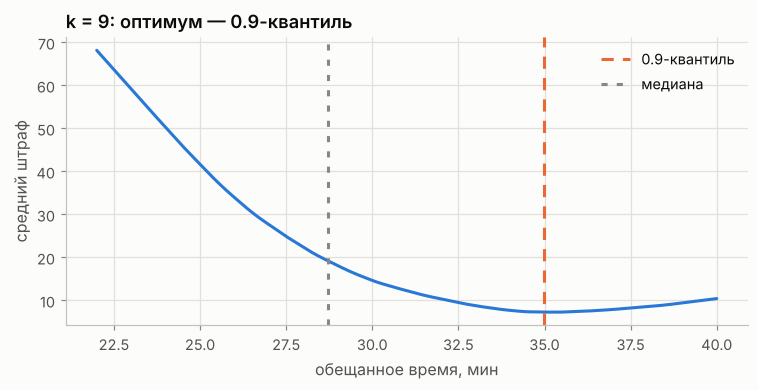

In [8]:
rng = Mulberry32(7)
times = np.array([22 + 6 * np.exp(0.55 * rng.normal()) for _ in range(60)])
for k in (1, 4, 9, 19):
    alpha = k / (k + 1)
    best = np.sort(times)[int(np.ceil(alpha * len(times))) - 1]
    print(f"k = {k:2d}: α = {alpha:.3f}, обещать {best:.1f} мин, опозданий {np.mean(times > best):.0%}")

k = 9
cost = lambda c: np.mean(np.where(times > c, k * (times - c), c - times))  # noqa: E731
cc = np.linspace(22, 40, 361)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(cc, [cost(c) for c in cc], color=style.BLUE)
ax.axvline(np.sort(times)[53], color=style.ORANGE, ls=(0, (4, 3)), label="0.9-квантиль")
ax.axvline(np.median(times), color=style.MUTED, ls=(0, (2, 3)), label="медиана")
ax.set(xlabel="обещанное время, мин", ylabel="средний штраф", title="k = 9: оптимум — 0.9-квантиль")
ax.legend()
plt.show()

## 8. От константы к модели

Доставки зависят от расстояния. Делим расстояние на $k$ групп и в каждой ставим лучшую константу. При $k = 1$ это
константа шага 7; при больших $k$ ступеньки приближают условное среднее, медиану и квантиль. Проверим, как часто
обещание по 0.9-квантили выполняется на **новых** заказах — в целом, у близких и у дальних клиентов.

k =  1: на обучении 90%, на новых 86%; близкие 100%, дальние 60%; размеры групп 240–240
k =  4: на обучении 91%, на новых 89%; близкие 93%, дальние 87%; размеры групп 49–65
k = 12: на обучении 92%, на новых 87%; близкие 88%, дальние 85%; размеры групп 13–31


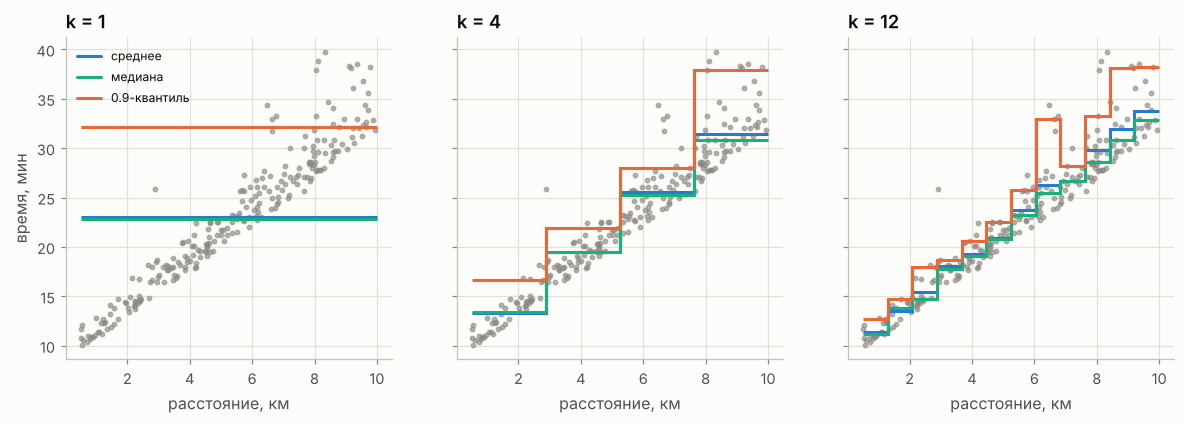

In [9]:
def deliveries(n: int, seed: int) -> tuple[np.ndarray, np.ndarray]:
    rng = Mulberry32(seed)
    x, y = [], []
    for _ in range(n):
        xi = rng.uniform(0.5, 10)
        z = rng.normal()
        x.append(xi)
        y.append(8 + 2.2 * xi + (1 + 0.35 * xi) * np.exp(0.6 * z))
    return np.array(x), np.array(y)


def exact_quantile(v: np.ndarray, alpha: float) -> float:
    return float(np.sort(v)[int(np.ceil(alpha * len(v) - 1e-9)) - 1])


xd, yd = deliveries(240, 21)
xn, yn = deliveries(240, 22)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, k in zip(axes, (1, 4, 12)):
    group = lambda v, k=k: np.minimum(((v - 0.5) / 9.5 * k).astype(int), k - 1)  # noqa: E731
    g, gn = group(xd), group(xn)
    edges = np.linspace(0.5, 10, k + 1)
    means = [yd[g == j].mean() for j in range(k)]
    medians = [np.median(yd[g == j]) for j in range(k)]
    q = np.array([exact_quantile(yd[g == j], 0.9) for j in range(k)])
    cover = yn <= q[gn]
    print(f"k = {k:2d}: на обучении {np.mean(yd <= q[g]):.0%}, на новых {cover.mean():.0%}; "
          f"близкие {cover[xn < 3.5].mean():.0%}, дальние {cover[xn > 7].mean():.0%}; размеры групп {np.bincount(g).min()}–{np.bincount(g).max()}")
    ax.scatter(xd, yd, s=8, color=style.MUTED, alpha=0.6)
    ax.stairs(means, edges, color=style.BLUE, lw=2, label="среднее", baseline=None)
    ax.stairs(medians, edges, color=style.AQUA, lw=2, label="медиана", baseline=None)
    ax.stairs(q, edges, color=style.ORANGE, lw=2, label="0.9-квантиль", baseline=None)
    ax.set(title=f"k = {k}", xlabel="расстояние, км")
axes[0].set_ylabel("время, мин")
axes[0].legend(fontsize=8)
plt.show()

## 9. Шум и правдоподобие

Потеря — минус логарифм плотности шума. Подгоним к 300 остаткам нормальный закон и закон Лапласа и сравним
средний $-\ln p$ (меньше — правдоподобнее).

normal    −ln p: нормальный 1.357, Лаплас 1.416 → L2
laplace   −ln p: нормальный 1.385, Лаплас 1.331 → L1
outliers  −ln p: нормальный 1.765, Лаплас 1.627 → L1


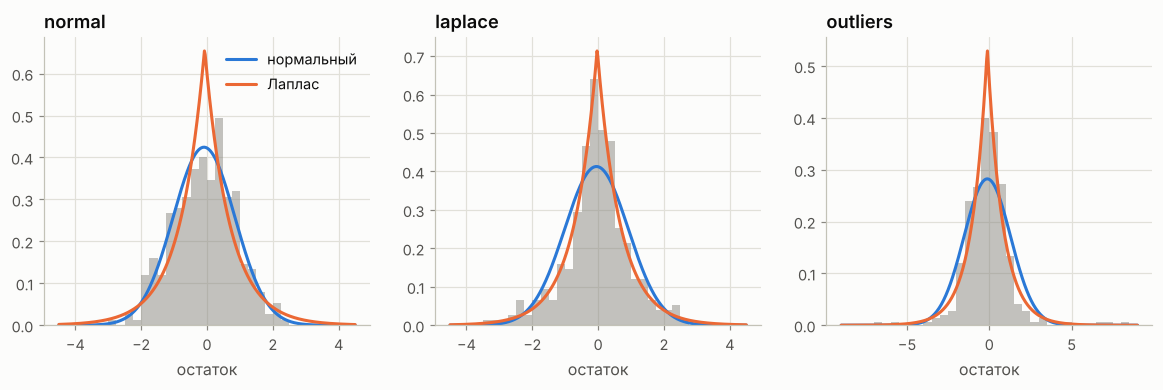

In [10]:
def noise(kind: str, n: int = 300, seed: int = 31) -> np.ndarray:
    rng = Mulberry32(seed)
    out = []
    for _ in range(n):
        if kind == "normal":
            v = rng.normal()
        elif kind == "laplace":
            u = rng.uniform(-0.5, 0.5)
            v = -np.sign(u) * np.log(max(1e-12, 1 - 2 * abs(u))) / np.sqrt(2)
        else:
            v = rng.normal()
            if rng.random() < 0.1:
                v *= 6
        out.append(v)
    return np.array(out)


fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, kind in zip(axes, ("normal", "laplace", "outliers")):
    rn = noise(kind)
    mu, sd, md = rn.mean(), rn.std(), np.median(rn)
    b = np.mean(np.abs(rn - md))
    nll_n = np.mean(0.5 * np.log(2 * np.pi * sd**2) + (rn - mu) ** 2 / (2 * sd**2))
    nll_l = np.mean(np.log(2 * b) + np.abs(rn - md) / b)
    print(f"{kind:9s} −ln p: нормальный {nll_n:.3f}, Лаплас {nll_l:.3f} → {'L2' if nll_n < nll_l else 'L1'}")
    R = 4.5 if kind != "outliers" else 9
    grid_r = np.linspace(-R, R, 400)
    ax.hist(rn, bins=36, range=(-R, R), density=True, color=style.MUTED, alpha=0.5)
    ax.plot(grid_r, np.exp(-(grid_r - mu) ** 2 / (2 * sd**2)) / np.sqrt(2 * np.pi * sd**2), color=style.BLUE, label="нормальный")
    ax.plot(grid_r, np.exp(-np.abs(grid_r - md) / b) / (2 * b), color=style.ORANGE, label="Лаплас")
    ax.set(title=kind, xlabel="остаток")
axes[0].legend()
plt.show()

## 10. Псевдо-остатки и бустинг с разными потерями

Данные с двумя выбросами. Сравним, чему учится первое дерево, и как ведёт себя весь бустинг.

squared  F0 = +0.453, max |псевдо-остаток| = 6.61
absolute F0 = +0.196, max |псевдо-остаток| = 1.00
huber    F0 = +0.196, max |псевдо-остаток| = 1.00
squared  min_samples_leaf = 1: MSE на чистых данных 4.077
squared  min_samples_leaf = 5: MSE на чистых данных 1.160
absolute min_samples_leaf = 1: MSE на чистых данных 0.155
absolute min_samples_leaf = 5: MSE на чистых данных 0.150


huber    min_samples_leaf = 1: MSE на чистых данных 4.111
huber    min_samples_leaf = 5: MSE на чистых данных 0.170


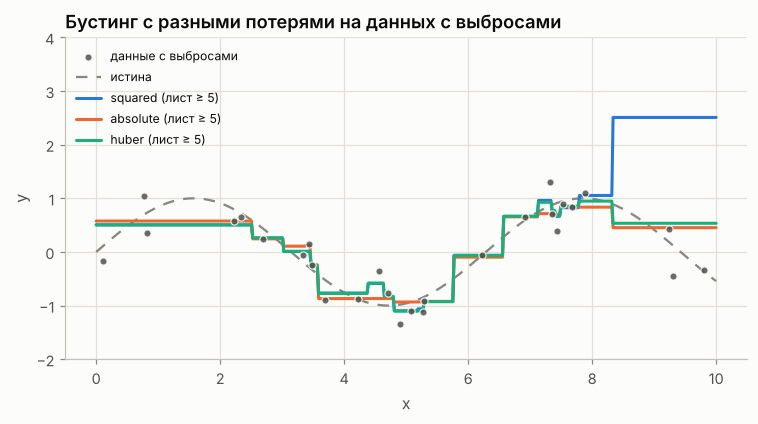

In [11]:
X, yo = datasets.regression_1d(kind="sine", n=30, noise=0.25, seed=4, outliers=0.1)
for name, kw in [("squared", {}), ("absolute", {}), ("huber", {"delta": 1.0})]:
    loss = get_loss(name, **kw)
    g = loss.negative_gradient(yo, np.full_like(yo, loss.init(yo)))
    print(f"{name:8s} F0 = {loss.init(yo):+.3f}, max |псевдо-остаток| = {np.abs(g).max():.2f}")

Xn, yn_sine = datasets.regression_1d(kind="sine", n=300, noise=0.25, seed=104)
xs = np.linspace(0, 10, 500).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(8, 3.8))
plot_data(ax, X, yo, label="данные с выбросами")
plot_truth(ax, "sine", label="истина")
for (name, kw), color in zip([("squared", {}), ("absolute", {}), ("huber", {"huber_delta": 1.0})], style.SERIES):
    for msl in (1, 5):
        gb = GBRegressor(loss=name, n_estimators=100, learning_rate=0.1, max_depth=2, min_samples_leaf=msl, **kw).fit(X, yo)
        print(f"{name:8s} min_samples_leaf = {msl}: MSE на чистых данных {mse(yn_sine, gb.predict(Xn)):.3f}")
    ax.plot(xs[:, 0], gb.predict(xs), color=color, lw=2, label=f"{name} (лист ≥ 5)")
ax.set(xlabel="x", ylabel="y", ylim=(-2, 4), title="Бустинг с разными потерями на данных с выбросами")
ax.legend(fontsize=8)
plt.show()

Хьюбер без ограничения на листья почти так же плох, как квадратичные потери: псевдо-остаток выброса обрезан,
но остаётся самым большим, дерево отрезает выброс в отдельный лист, а значение листа — лучшая константа для
одного объекта — равно всему его остатку. С `min_samples_leaf=5` выброс больше не получает свой лист.

## 11. Классификация: log-loss, лучшая вероятность и отступ

Лучшая константа-вероятность — доля класса 1; бустинг стартует с её логита. В координатах отступа
$m = \tilde y F$ видно, что log-loss и экспоненциальная потеря — гладкие «заменители» ступеньки 0–1.

y = 1, p =  0.9: log-loss = 0.105
y = 1, p =  0.5: log-loss = 0.693
y = 1, p =  0.1: log-loss = 2.303
y = 1, p = 0.01: log-loss = 4.605
численный минимум: 0.3   доля класса 1: 0.3   стартовый логит: -0.8472978603872036
gbcourse logistic init: -0.8472978603872036


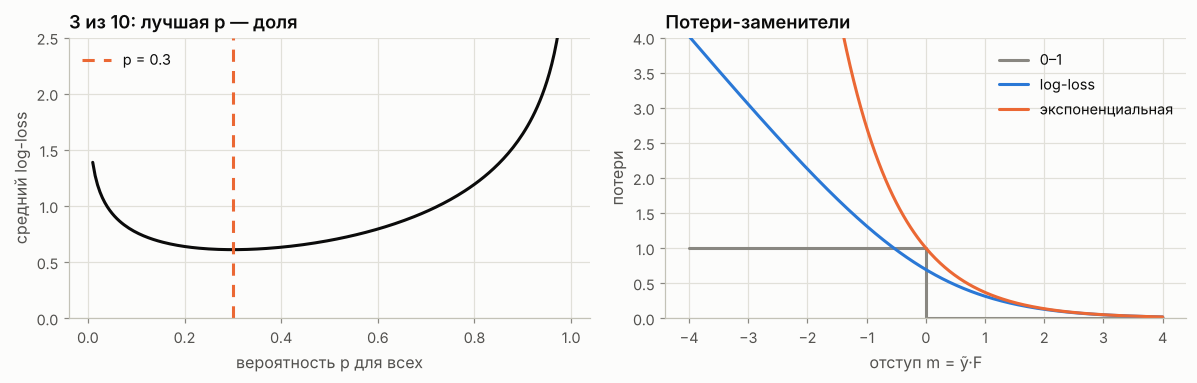

In [12]:
for p in (0.9, 0.5, 0.1, 0.01):
    print(f"y = 1, p = {p:4}: log-loss = {-np.log(p):.3f}")
labels = np.array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0])
ps = np.linspace(0.01, 0.99, 197)
risk = [-np.mean(labels * np.log(p) + (1 - labels) * np.log(1 - p)) for p in ps]
p_hat = labels.mean()
print("численный минимум:", ps[int(np.argmin(risk))], "  доля класса 1:", p_hat, "  стартовый логит:", np.log(p_hat / (1 - p_hat)))
print("gbcourse logistic init:", get_loss("logistic").init(labels))

ms = np.linspace(-4, 4, 401)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(ps, risk, color=style.INK)
axes[0].axvline(p_hat, color=style.ORANGE, ls=(0, (4, 3)), label="p = 0.3")
axes[0].set(xlabel="вероятность p для всех", ylabel="средний log-loss", title="3 из 10: лучшая p — доля", ylim=(0, 2.5))
axes[0].legend()
axes[1].step(ms, (ms < 0).astype(float), where="post", color=style.MUTED, label="0–1")
axes[1].plot(ms, np.log1p(np.exp(-ms)), color=style.BLUE, label="log-loss")
axes[1].plot(ms, np.exp(-ms), color=style.ORANGE, label="экспоненциальная")
axes[1].set(xlabel="отступ m = ỹ·F", ylabel="потери", ylim=(0, 4), title="Потери-заменители")
axes[1].legend()
fig.tight_layout()
plt.show()

## 12. Первый шаг бустинга руками

$x = 1..5$, $y = (1, 2, 3, 4, 10)$. Старт — лучшая константа, дерево-пень делит по псевдо-остаткам,
а в лист ставит лучшую константу для самих потерь. Сверяем с одним деревом `GBRegressor`.

In [13]:
x5 = np.arange(1, 6.0)
for name, kw, gb_kw in [("squared", {}, {}), ("absolute", {}, {}), ("huber", {"delta": 3.0}, {"huber_delta": 3.0})]:
    loss = get_loss(name, **kw)
    F = np.full_like(y, loss.init(y))
    g = loss.negative_gradient(y, F)
    sse = {t: sum(((g[m] - g[m].mean()) ** 2).sum() for m in (x5 < t, x5 > t)) for t in (1.5, 2.5, 3.5, 4.5)}
    t = min(sse, key=sse.get)
    left = x5 < t
    gamma = (loss.leaf_value(y[left], F[left]), loss.leaf_value(y[~left], F[~left]))
    F1 = F + np.where(left, *gamma)
    gb = GBRegressor(loss=name, n_estimators=1, learning_rate=1.0, max_depth=1, **gb_kw).fit(x5.reshape(-1, 1), y)
    print(f"{name:8s} F0 = {F[0]}, g = {g}, разбиение x ≤ {t}, γ = ({gamma[0]:+.2f}, {gamma[1]:+.2f}), F1 = {F1}, "
          f"потери {loss.loss(y, F):.2f} → {loss.loss(y, F1):.2f}; совпадает с GBRegressor: {np.allclose(gb.predict(x5.reshape(-1, 1)), F1)}")

squared  F0 = 4.0, g = [-3. -2. -1. -0.  6.], разбиение x ≤ 4.5, γ = (-1.50, +6.00), F1 = [ 2.5  2.5  2.5  2.5 10. ], потери 5.00 → 0.50; совпадает с GBRegressor: True
absolute F0 = 3.0, g = [-1. -1. -0.  1.  1.], разбиение x ≤ 2.5, γ = (-1.50, +1.00), F1 = [1.5 1.5 4.  4.  4. ], потери 2.20 → 1.60; совпадает с GBRegressor: True
huber    F0 = 3.0, g = [-2. -1.  0.  1.  3.], разбиение x ≤ 3.5, γ = (-1.00, +4.00), F1 = [2. 2. 2. 7. 7.], потери 3.90 → 2.00; совпадает с GBRegressor: True


## 13. Сверка с scikit-learn: стартовые константы бустинга

In [14]:
from sklearn.ensemble import GradientBoostingRegressor

X5 = np.arange(5.0).reshape(-1, 1)
for loss in ("squared_error", "absolute_error", "huber"):
    gb = GradientBoostingRegressor(loss=loss, n_estimators=1).fit(X5, y)
    print(f"{loss:15s} F0 = {gb.init_.predict(X5)[0]:.3f}")
gq = GradientBoostingRegressor(loss="quantile", alpha=0.9, n_estimators=1).fit(X5, y)
print(f"{'quantile 0.9':15s} F0 = {gq.init_.predict(X5)[0]:.3f}")

squared_error   F0 = 4.000
absolute_error  F0 = 3.000
huber           F0 = 3.000
quantile 0.9    F0 = 7.600


## Упражнения

1. Для $y = \{1, 2, 3, 100\}$ постройте $\sum|y_i - c|$ на $[0, 5]$ и объясните плато на $[2, 3]$.
2. Найдите лучшую константу Хьюбера для $(1, 2, 3, 4, 10)$ при $\delta = 4$ руками и численно.
3. Для $y = \{2.1, \dots, 6.2, 11.5\}$ найдите оптимум Хьюбера при $\delta \in \{0.1, 0.5, 1, 3, 10\}$.
   К чему он стремится при $\delta \to 0$ и $\delta \to \infty$?
4. Булочная теряет 90 ₽ на непроданной булке и 10 ₽ на упущенном покупателе. Какую квантиль спроса печь?
5. Выведите псевдо-остатки потерь Хьюбера и проверьте их непрерывность.
6. Сравните бустинг с разными потерями на данных с выбросами (раздел 10).
7. Пример метрики, не совпадающей с потерей.
8. Посчитайте риск шести квартир руками для четырёх потерь (раздел 2).
9. Докажите, что лучшая константа для log-loss — доля класса 1; найдите стартовый логит для 2 из 10.
10. Повторите первый шаг бустинга с L1 для разбиения $x \le 3.5$ и объясните, почему маленький лист лишает L1 устойчивости.
11. Обучите бустинг с квантильными потерями на доставках и проверьте покрытие на новых данных у близких и дальних клиентов.
12. Покажите численно, что для шума Лапласа медиана — оценка максимального правдоподобия центра.

<details><summary>Решения</summary>

`python lessons/lesson_1_2/exercises/solutions.py`
</details>